In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, MeanShift

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [2]:
# Step 2: Load Dataset
data = load_iris()
X = data.data

print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [3]:
# Step 3: Define Function for Evaluation
def evaluate_clustering(X, labels):
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    
    return sil, ch, db

In [4]:
# Step 4: Preprocessing Methods
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_norm_pca = pca.fit_transform(X_norm)

In [5]:
# Step 5: Clustering Models
def run_kmeans(X, clusters):
    model = KMeans(n_clusters=clusters, random_state=0)
    labels = model.fit_predict(X)
    return evaluate_clustering(X, labels)


def run_hierarchical(X, clusters):
    model = AgglomerativeClustering(n_clusters=clusters)
    labels = model.fit_predict(X)
    return evaluate_clustering(X, labels)


def run_meanshift(X):
    model = MeanShift()
    labels = model.fit_predict(X)
    return evaluate_clustering(X, labels)

In [6]:
# Step 6: Run Experiments
cluster_values = [3, 4, 5]

print("\n===== K-MEANS =====")
for c in cluster_values:
    print("Clusters =", c)
    
    print("No Processing:", run_kmeans(X, c))
    print("Normalization:", run_kmeans(X_norm, c))
    print("PCA:", run_kmeans(X_pca, c))
    print("Norm + PCA:", run_kmeans(X_norm_pca, c))
    print()


print("\n===== HIERARCHICAL =====")
for c in cluster_values:
    print("Clusters =", c)
    
    print("No Processing:", run_hierarchical(X, c))
    print("Normalization:", run_hierarchical(X_norm, c))
    print("PCA:", run_hierarchical(X_pca, c))
    print("Norm + PCA:", run_hierarchical(X_norm_pca, c))
    print()


print("\n===== MEAN SHIFT =====")
print("No Processing:", run_meanshift(X))
print("Normalization:", run_meanshift(X_norm))
print("PCA:", run_meanshift(X_pca))
print("Norm + PCA:", run_meanshift(X_norm_pca))


===== K-MEANS =====
Clusters = 3
No Processing: (0.551191604619592, 561.593732015664, 0.6660385791628493)
Normalization: (0.45994823920518635, 241.90440170183157, 0.8335949464754338)
PCA: (0.5976764219547992, 693.708433418848, 0.5648157434964134)
Norm + PCA: (0.5091683341538227, 293.8565155630172, 0.7099307974801775)

Clusters = 4
No Processing: (0.49805050499728737, 530.7658081872851, 0.7803069838811107)
Normalization: (0.38694104154427816, 207.26591431569688, 0.8698143723183839)
PCA: (0.5609574019832676, 715.9032209990701, 0.6197127281728918)
Norm + PCA: (0.4570932824061394, 261.70739740270506, 0.7231631147819901)

Clusters = 5
No Processing: (0.4609502384437903, 459.4514701701039, 0.9153143340175232)
Normalization: (0.34551099599809465, 203.2674193279362, 0.9451729577717423)
PCA: (0.5459750538747975, 683.6782055008532, 0.6485369485245877)
Norm + PCA: (0.4258882269996361, 274.81999636700823, 0.7531187936967277)


===== HIERARCHICAL =====
Clusters = 3
No Processing: (0.55432366112964

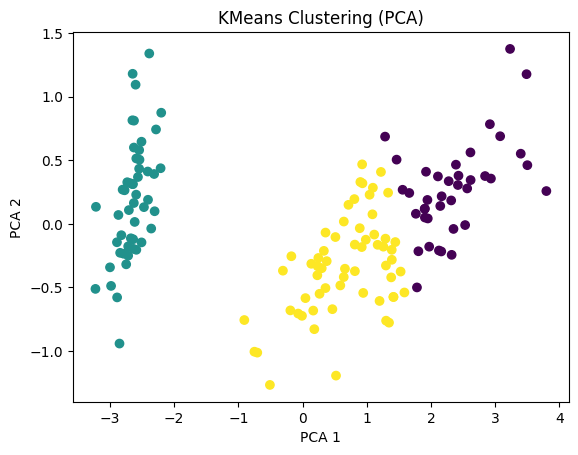

In [7]:
# Step 7: Visualization
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("KMeans Clustering (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()